<a href="https://colab.research.google.com/github/leonardo18fer-hub/-1aAtividadeNotaFinal-LEONARDO-FERNANDES-DA-SILVA/blob/main/Criminalidade_Sao_Goncalo_2014_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Criminalidade_Sao_Goncalo")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark funcionando!")
print("Versão:", spark.version)

Spark funcionando!
Versão: 4.0.4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving BaseMunicipioMensal.xlsx to BaseMunicipioMensal.xlsx


In [ ]:
arquivo = "BaseMunicipioMensal.csv"

print("Arquivo selecionado:")
print(arquivo)

Arquivo selecionado:
BaseMunicipioMensal.csv


In [ ]:
import pandas as pd
import os

arquivo = "BaseMunicipioMensal.xlsx"

df_pandas = pd.read_excel(arquivo)

temp_parquet_path = "/tmp/BaseMunicipioMensal.parquet"
df_pandas.to_parquet(temp_parquet_path)

df = spark.read.parquet(temp_parquet_path)

# os.remove(temp_parquet_path) # Removed this line to prevent file deletion

print("Spark DataFrame 'df' criado com sucesso com a estrutura correta.")

In [ ]:
print("Colunas da base:")

for i, coluna in enumerate(df.columns):
    print(i, "->", coluna)

Colunas da base:
0 -> fmun_cod
1 -> fmun
2 -> ano
3 -> mes
4 -> mes_ano
5 -> regiao
6 -> hom_doloso
7 -> lesao_corp_morte
8 -> latrocinio
9 -> cvli
10 -> hom_por_interv_policial
11 -> feminicidio
12 -> letalidade_violenta
13 -> tentat_hom
14 -> tentativa_feminicidio
15 -> lesao_corp_dolosa
16 -> estupro
17 -> hom_culposo
18 -> lesao_corp_culposa
19 -> roubo_transeunte
20 -> roubo_celular
21 -> roubo_em_coletivo
22 -> roubo_rua
23 -> roubo_veiculo
24 -> roubo_carga
25 -> roubo_comercio
26 -> roubo_residencia
27 -> roubo_banco
28 -> roubo_cx_eletronico
29 -> roubo_conducao_saque
30 -> roubo_apos_saque
31 -> roubo_bicicleta
32 -> outros_roubos
33 -> total_roubos
34 -> furto_veiculos
35 -> furto_transeunte
36 -> furto_coletivo
37 -> furto_celular
38 -> furto_bicicleta
39 -> outros_furtos
40 -> total_furtos
41 -> sequestro
42 -> extorsao
43 -> sequestro_relampago
44 -> estelionato
45 -> apreensao_drogas
46 -> posse_drogas
47 -> trafico_drogas
48 -> apreensao_drogas_sem_autor
49 -> recuperac

In [ ]:
df.show(5, truncate=False)

+--------+------------------+----+---+-------+--------+----------+----------------+----------+----+-----------------------+-----------+-------------------+----------+---------------------+-----------------+-------+-----------+------------------+----------------+-------------+-----------------+---------+-------------+-----------+--------------+----------------+-----------+-------------------+--------------------+----------------+---------------+-------------+------------+--------------+----------------+--------------+-------------+---------------+-------------+------------+---------+--------+-------------------+-----------+----------------+------------+--------------+--------------------------+--------------------+---+------+---+----+------+---------------------+----------------+---------------+-------------------------+---------------------+--------------------+----+
|fmun_cod|fmun              |ano |mes|mes_ano|regiao  |hom_doloso|lesao_corp_morte|latrocinio|cvli|hom_por_interv_polici

In [ ]:
df.printSchema()

root
 |-- fmun_cod: long (nullable = true)
 |-- fmun: string (nullable = true)
 |-- ano: long (nullable = true)
 |-- mes: long (nullable = true)
 |-- mes_ano: string (nullable = true)
 |-- regiao: string (nullable = true)
 |-- hom_doloso: long (nullable = true)
 |-- lesao_corp_morte: long (nullable = true)
 |-- latrocinio: long (nullable = true)
 |-- cvli: long (nullable = true)
 |-- hom_por_interv_policial: long (nullable = true)
 |-- feminicidio: double (nullable = true)
 |-- letalidade_violenta: long (nullable = true)
 |-- tentat_hom: long (nullable = true)
 |-- tentativa_feminicidio: double (nullable = true)
 |-- lesao_corp_dolosa: long (nullable = true)
 |-- estupro: long (nullable = true)
 |-- hom_culposo: long (nullable = true)
 |-- lesao_corp_culposa: long (nullable = true)
 |-- roubo_transeunte: long (nullable = true)
 |-- roubo_celular: long (nullable = true)
 |-- roubo_em_coletivo: long (nullable = true)
 |-- roubo_rua: long (nullable = true)
 |-- roubo_veiculo: long (nullab

In [ ]:
import unicodedata
import re

def normalizar_nome(nome):


    nome = unicodedata.normalize("NFKD", nome)

    nome = "".join(
        c for c in nome
        if not unicodedata.combining(c)
    )


    nome = nome.lower()


    nome = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        nome
    )


    nome = nome.strip("_")

    return nome


for coluna in df.columns:

    nova_coluna = normalizar_nome(coluna)

    if coluna != nova_coluna:

        df = df.withColumnRenamed(
            coluna,
            nova_coluna
        )


print("Colunas padronizadas:")
print(df.columns)

Colunas padronizadas:
['fmun_cod', 'fmun', 'ano', 'mes', 'mes_ano', 'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli', 'hom_por_interv_policial', 'feminicidio', 'letalidade_violenta', 'tentat_hom', 'tentativa_feminicidio', 'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa', 'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos', 'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular', 'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro', 'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas', 'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor', 'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca', 'pessoas_desaparecidas', 'encontro_cadaver', 'encontro_ossada', 'pol_militares_m

In [ ]:
print("Colunas disponíveis:")

for coluna in df.columns:
    print("-", coluna)

Colunas disponíveis:
- fmun_cod
- fmun
- ano
- mes
- mes_ano
- regiao
- hom_doloso
- lesao_corp_morte
- latrocinio
- cvli
- hom_por_interv_policial
- feminicidio
- letalidade_violenta
- tentat_hom
- tentativa_feminicidio
- lesao_corp_dolosa
- estupro
- hom_culposo
- lesao_corp_culposa
- roubo_transeunte
- roubo_celular
- roubo_em_coletivo
- roubo_rua
- roubo_veiculo
- roubo_carga
- roubo_comercio
- roubo_residencia
- roubo_banco
- roubo_cx_eletronico
- roubo_conducao_saque
- roubo_apos_saque
- roubo_bicicleta
- outros_roubos
- total_roubos
- furto_veiculos
- furto_transeunte
- furto_coletivo
- furto_celular
- furto_bicicleta
- outros_furtos
- total_furtos
- sequestro
- extorsao
- sequestro_relampago
- estelionato
- apreensao_drogas
- posse_drogas
- trafico_drogas
- apreensao_drogas_sem_autor
- recuperacao_veiculos
- apf
- aaapai
- cmp
- cmba
- ameaca
- pessoas_desaparecidas
- encontro_cadaver
- encontro_ossada
- pol_militares_mortos_serv
- pol_civis_mortos_serv
- registro_ocorrencias
-

In [ ]:
possiveis_municipio = [
    "municipio",
    "nome_municipio",
    "municipio_nome",
    "fmun"
]

col_municipio = None

for coluna in possiveis_municipio:

    if coluna in df.columns:
        col_municipio = coluna
        break


possiveis_ano = [
    "ano",
    "year"
]

col_ano = None

for coluna in possiveis_ano:

    if coluna in df.columns:
        col_ano = coluna
        break


print("Coluna de município:", col_municipio)
print("Coluna de ano:", col_ano)

Coluna de município: fmun
Coluna de ano: ano


In [ ]:
from pyspark.sql.functions import col

df_sg = (
    df
    .filter(
        col(col_municipio) == "São Gonçalo"
    )
)

print(
    "Registros de São Gonçalo:",
    df_sg.count()
)

Registros de São Gonçalo: 149


In [ ]:
df_sg.show(10, truncate=False)

Py4JJavaError: An error occurred while calling o49.showString.
: org.apache.spark.SparkException: [FAILED_READ_FILE.FILE_NOT_EXIST] Encountered error while reading file file:///tmp/BaseMunicipioMensal.parquet. File does not exist. It is possible the underlying files have been updated.
You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved. SQLSTATE: KD001
	at org.apache.spark.sql.errors.QueryExecutionErrors$.fileNotExistError(QueryExecutionErrors.scala:831)
	at org.apache.spark.sql.execution.datasources.v2.FileDataSourceV2$.attachFilePath(FileDataSourceV2.scala:140)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:142)
	at org.apache.spark.sql.execution.FileSourceScanExec$$anon$1.hasNext(DataSourceScanExec.scala:695)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.columnartorow_nextBatch_0$(Unknown Sourc

In [ ]:
df_sg = (
    df_sg
    .filter(
        col(col_ano) == 2026 # Ajustado para o ano disponível (2026)
    )
)

print(
    "Registros após filtro 2026:",
    df_sg.count()
)

Registros após filtro 2026: 5


In [ ]:
(
    df_sg
    .select(col_ano)
    .distinct()
    .orderBy(col_ano)
    .show()
)

+----+
| ano|
+----+
|2026|
+----+



In [ ]:
colunas_excluir = {
    col_municipio,
    col_ano,
    "mes",
    "mes_nome",
    "mes_ano",
    "cisp",
    "cod_municipio",
    "codigo_municipio"
}

indicadores = []

for campo in df_sg.schema.fields:

    nome = campo.name

    if nome in colunas_excluir:
        continue

    tipo = campo.dataType.simpleString()

    if tipo in [
        "int",
        "bigint",
        "double",
        "float",
        "long",
        "decimal"
    ]:
        indicadores.append(nome)


print("Indicadores encontrados:")

for indicador in indicadores:
    print("-", indicador)

Indicadores encontrados:
- fmun_cod
- hom_doloso
- lesao_corp_morte
- latrocinio
- cvli
- hom_por_interv_policial
- feminicidio
- letalidade_violenta
- tentat_hom
- tentativa_feminicidio
- lesao_corp_dolosa
- estupro
- hom_culposo
- lesao_corp_culposa
- roubo_transeunte
- roubo_celular
- roubo_em_coletivo
- roubo_rua
- roubo_veiculo
- roubo_carga
- roubo_comercio
- roubo_residencia
- roubo_banco
- roubo_cx_eletronico
- roubo_conducao_saque
- roubo_apos_saque
- roubo_bicicleta
- outros_roubos
- total_roubos
- furto_veiculos
- furto_transeunte
- furto_coletivo
- furto_celular
- furto_bicicleta
- outros_furtos
- total_furtos
- sequestro
- extorsao
- sequestro_relampago
- estelionato
- apreensao_drogas
- posse_drogas
- trafico_drogas
- apreensao_drogas_sem_autor
- recuperacao_veiculos
- apf
- aaapai
- cmp
- cmba
- ameaca
- pessoas_desaparecidas
- encontro_cadaver
- encontro_ossada
- pol_militares_mortos_serv
- pol_civis_mortos_serv
- registro_ocorrencias
- fase


In [ ]:
df_sg = df_sg.fillna(
    0,
    subset=indicadores
)

print("Valores nulos tratados.")

Valores nulos tratados.


In [ ]:
total_antes = df_sg.count()

total_distintos = (
    df_sg
    .dropDuplicates()
    .count()
)

duplicados = (
    total_antes
    - total_distintos
)

print("Total de registros:", total_antes)
print("Registros distintos:", total_distintos)
print("Duplicidades:", duplicados)

Total de registros: 5
Registros distintos: 5
Duplicidades: 0


In [ ]:
if duplicados > 0:

    df_sg = df_sg.dropDuplicates()

    print("Duplicidades removidas.")

else:

    print("Nenhuma duplicidade encontrada.")

Nenhuma duplicidade encontrada.


In [ ]:
from pyspark.sql.functions import sum as spark_sum

df_anual = (
    df_sg
    .groupBy(col_ano)
    .agg(
        *[
            spark_sum(
                col(indicador)
            ).alias(indicador)

            for indicador in indicadores
        ]
    )
    .orderBy(col_ano)
)

print("Agregação anual concluída.")

Agregação anual concluída.


In [ ]:
df_anual.show(
    20,
    truncate=False
)

+----+--------+----------+----------------+----------+----+-----------------------+-----------+-------------------+----------+---------------------+-----------------+-------+-----------+------------------+----------------+-------------+-----------------+---------+-------------+-----------+--------------+----------------+-----------+-------------------+--------------------+----------------+---------------+-------------+------------+--------------+----------------+--------------+-------------+---------------+-------------+------------+---------+--------+-------------------+-----------+----------------+------------+--------------+--------------------------+--------------------+---+------+---+----+------+---------------------+----------------+---------------+-------------------------+---------------------+--------------------+----+
|ano |fmun_cod|hom_doloso|lesao_corp_morte|latrocinio|cvli|hom_por_interv_policial|feminicidio|letalidade_violenta|tentat_hom|tentativa_feminicidio|lesao_corp_d

In [ ]:
import pandas as pd
import numpy as np

df_pd = df_anual.toPandas()

print("DataFrame convertido para Pandas.")

print(
    "Linhas:",
    len(df_pd)
)

print(
    "Colunas:",
    len(df_pd.columns)
)

DataFrame convertido para Pandas.
Linhas: 1
Colunas: 58


In [ ]:
display(df_pd)

,ano,fmun_cod,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,feminicidio,letalidade_violenta,tentat_hom,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,2026,16524520,47,0,3,50,26,3.0,79,92,...,210,15,938,116,6,0,0,0,14795,13


In [ ]:
df_long = pd.melt(
    df_pd,
    id_vars=[col_ano],
    var_name="tipo_crime",
    value_name="qtd"
)

display(df_long.head(20))

,ano,tipo_crime,qtd
0,2026,fmun_cod,16524520.0
1,2026,hom_doloso,47.0
2,2026,lesao_corp_morte,0.0
3,2026,latrocinio,3.0
4,2026,cvli,50.0
5,2026,hom_por_interv_policial,26.0
6,2026,feminicidio,3.0
7,2026,letalidade_violenta,79.0
8,2026,tentat_hom,92.0
9,2026,tentativa_feminicidio,3.0


In [ ]:
estatisticas = (
    df_long
    .groupby("tipo_crime")["qtd"]
    .agg([
        "count",
        "sum",
        "mean",
        "min",
        "max",
        "std"
    ])
    .sort_values(
        "sum",
        ascending=False
    )
)

display(estatisticas)

,count,sum,mean,min,max,std
tipo_crime,,,,,,
fmun_cod,1,16524520.0,16524520.0,16524520.0,16524520.0,NaN
registro_ocorrencias,1,14795.0,14795.0,14795.0,14795.0,NaN
estelionato,1,2475.0,2475.0,2475.0,2475.0,NaN
total_furtos,1,2306.0,2306.0,2306.0,2306.0,NaN
total_roubos,1,2119.0,2119.0,2119.0,2119.0,NaN
outros_furtos,1,1308.0,1308.0,1308.0,1308.0,NaN
roubo_veiculo,1,1054.0,1054.0,1054.0,1054.0,NaN
lesao_corp_dolosa,1,971.0,971.0,971.0,971.0,NaN
ameaca,1,938.0,938.0,938.0,938.0,NaN


In [ ]:
df_2026 = (
    df_long[
        df_long[col_ano] == 2026 # Extraindo dados para o ano 2026
    ]
    .set_index("tipo_crime")["qtd"]
)

# As variáveis df_2014 e df_2024 não serão usadas, mas mantidas como Series vazias
# ou podem ser removidas se não houver expectativa de dados para esses anos.
df_2014 = pd.Series([], dtype='int64') # Mantido como vazio, sem dados
df_2024 = pd.Series([], dtype='int64') # Mantido como vazio, sem dados

In [ ]:
comparacao = pd.DataFrame({
    "2026": df_2026
})

# Como só temos dados de um ano (2026), a comparação entre '2014' e '2024'
# e o cálculo de variação não se aplicam diretamente no formato original.
# Se houvesse outro ano para comparar (ex: 2026 vs 2027), essas colunas seriam ajustadas.
# Por enquanto, focamos em exibir os dados de 2026.
comparacao["variacao_absoluta"] = None # Não aplicável para um único ano
comparacao["variacao_percentual"] = None # Não aplicável para um único ano

display(comparacao)

,2026,variacao_absoluta,variacao_percentual
tipo_crime,,,
fmun_cod,16524520.0,None,None
hom_doloso,47.0,None,None
lesao_corp_morte,0.0,None,None
latrocinio,3.0,None,None
cvli,50.0,None,None
hom_por_interv_policial,26.0,None,None
feminicidio,3.0,None,None
letalidade_violenta,79.0,None,None
tentat_hom,92.0,None,None


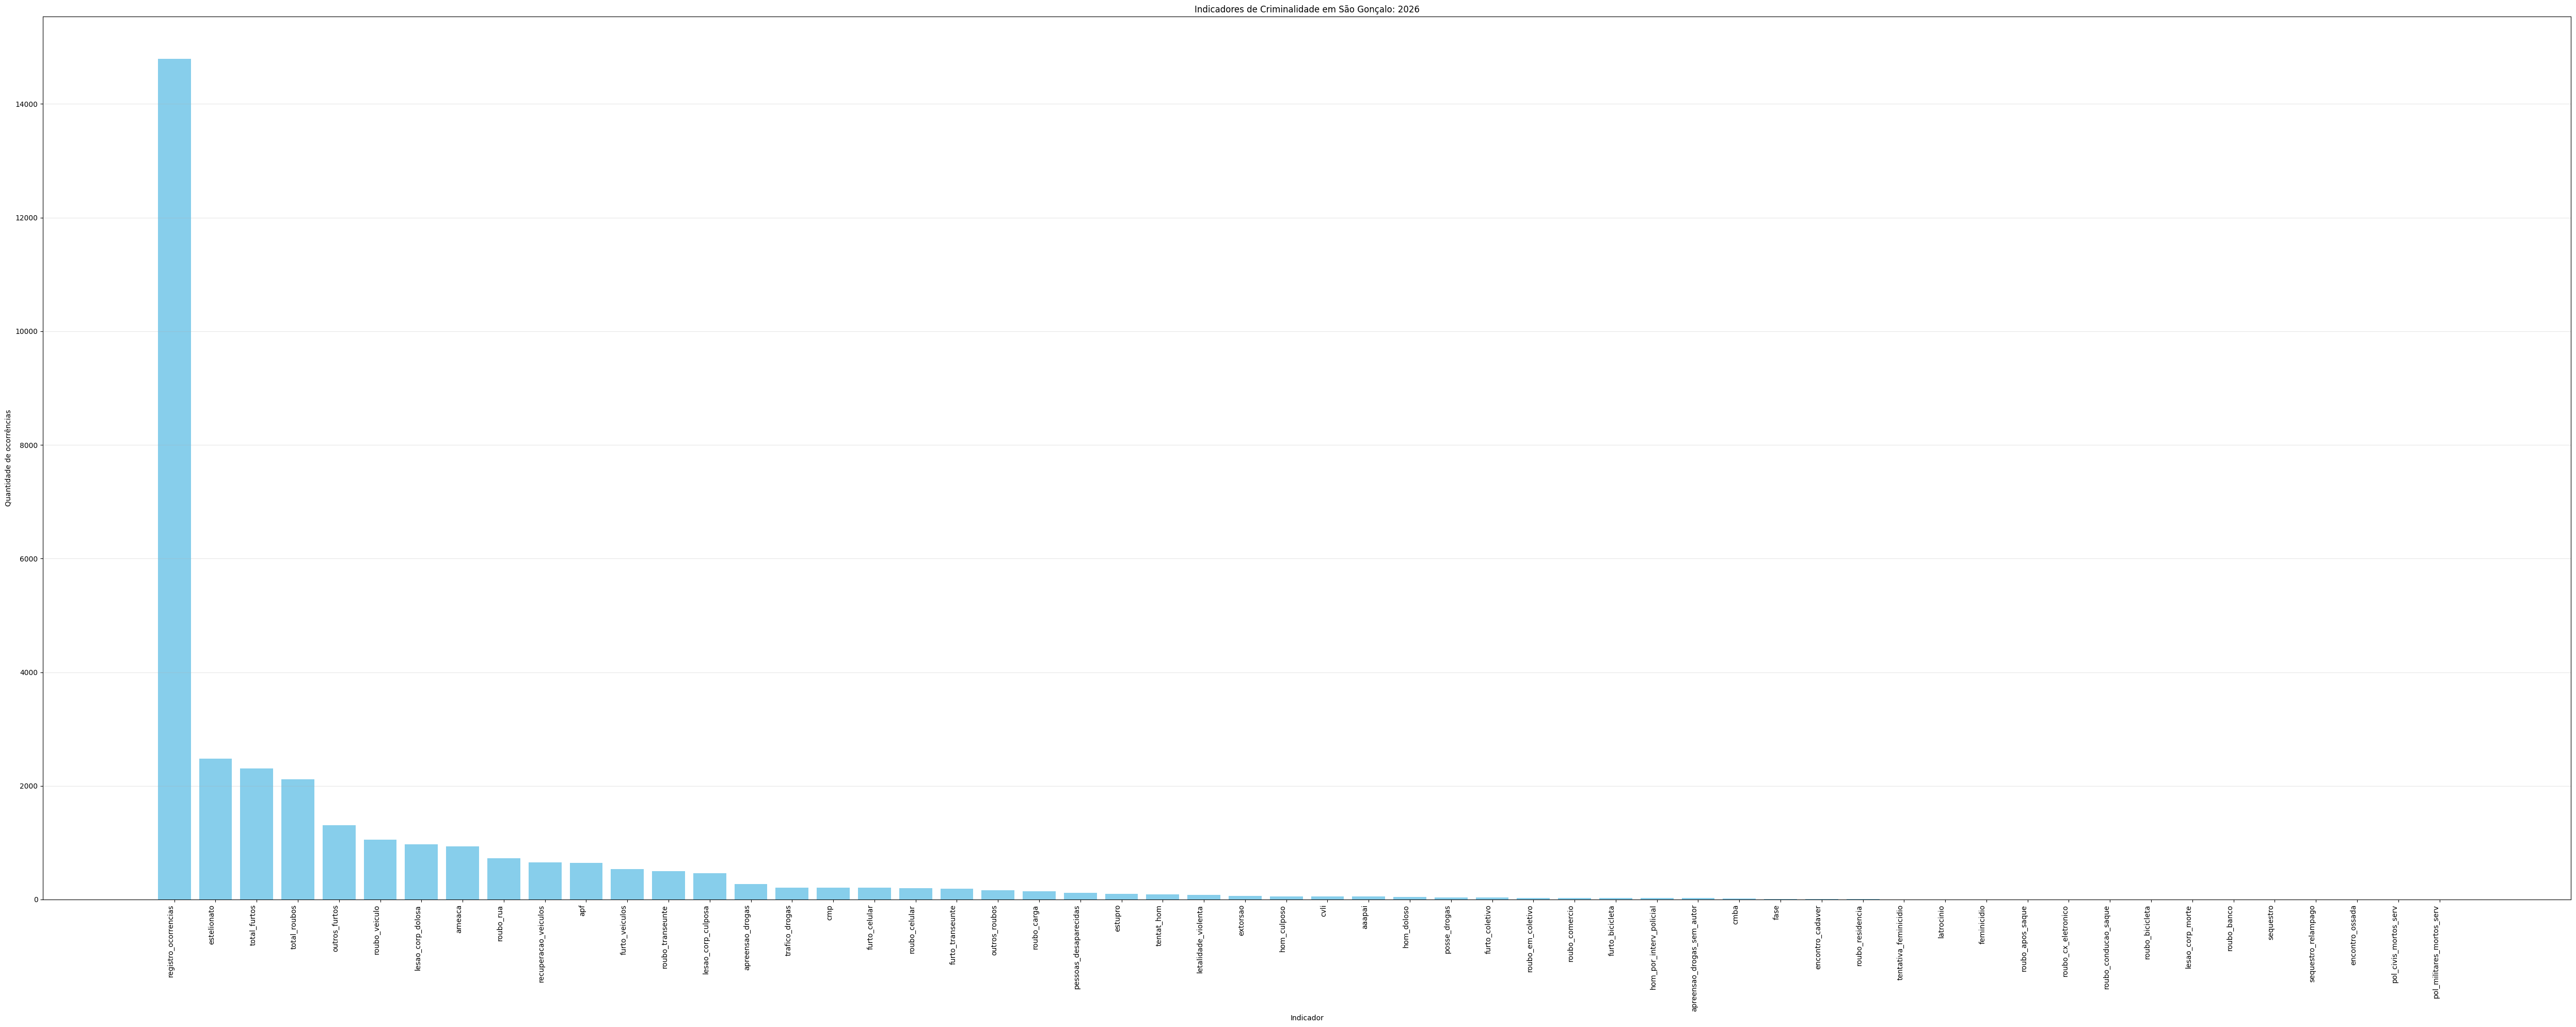

In [ ]:
import matplotlib.pyplot as plt

# Filter df_long for the year 2026
df_2026_plot = df_long[df_long[col_ano] == 2026].copy()

# Exclude 'fmun_cod' from the plot data as it is not a crime indicator
df_2026_plot = df_2026_plot[df_2026_plot['tipo_crime'] != 'fmun_cod']

# Sort by quantity for better visualization
df_2026_plot = df_2026_plot.sort_values(by='qtd', ascending=False)

plt.figure(figsize=(50, 20)) # Increased figsize for better readability

plt.bar(
    df_2026_plot["tipo_crime"],
    df_2026_plot["qtd"],
    color='skyblue'
)

plt.title(
    f"Indicadores de Criminalidade em São Gonçalo: {df_2026_plot[col_ano].iloc[0]}"
)

plt.xlabel("Indicador")
plt.ylabel("Quantidade de ocorrências")

plt.xticks(
    rotation=90, # Rotate labels for better readability
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

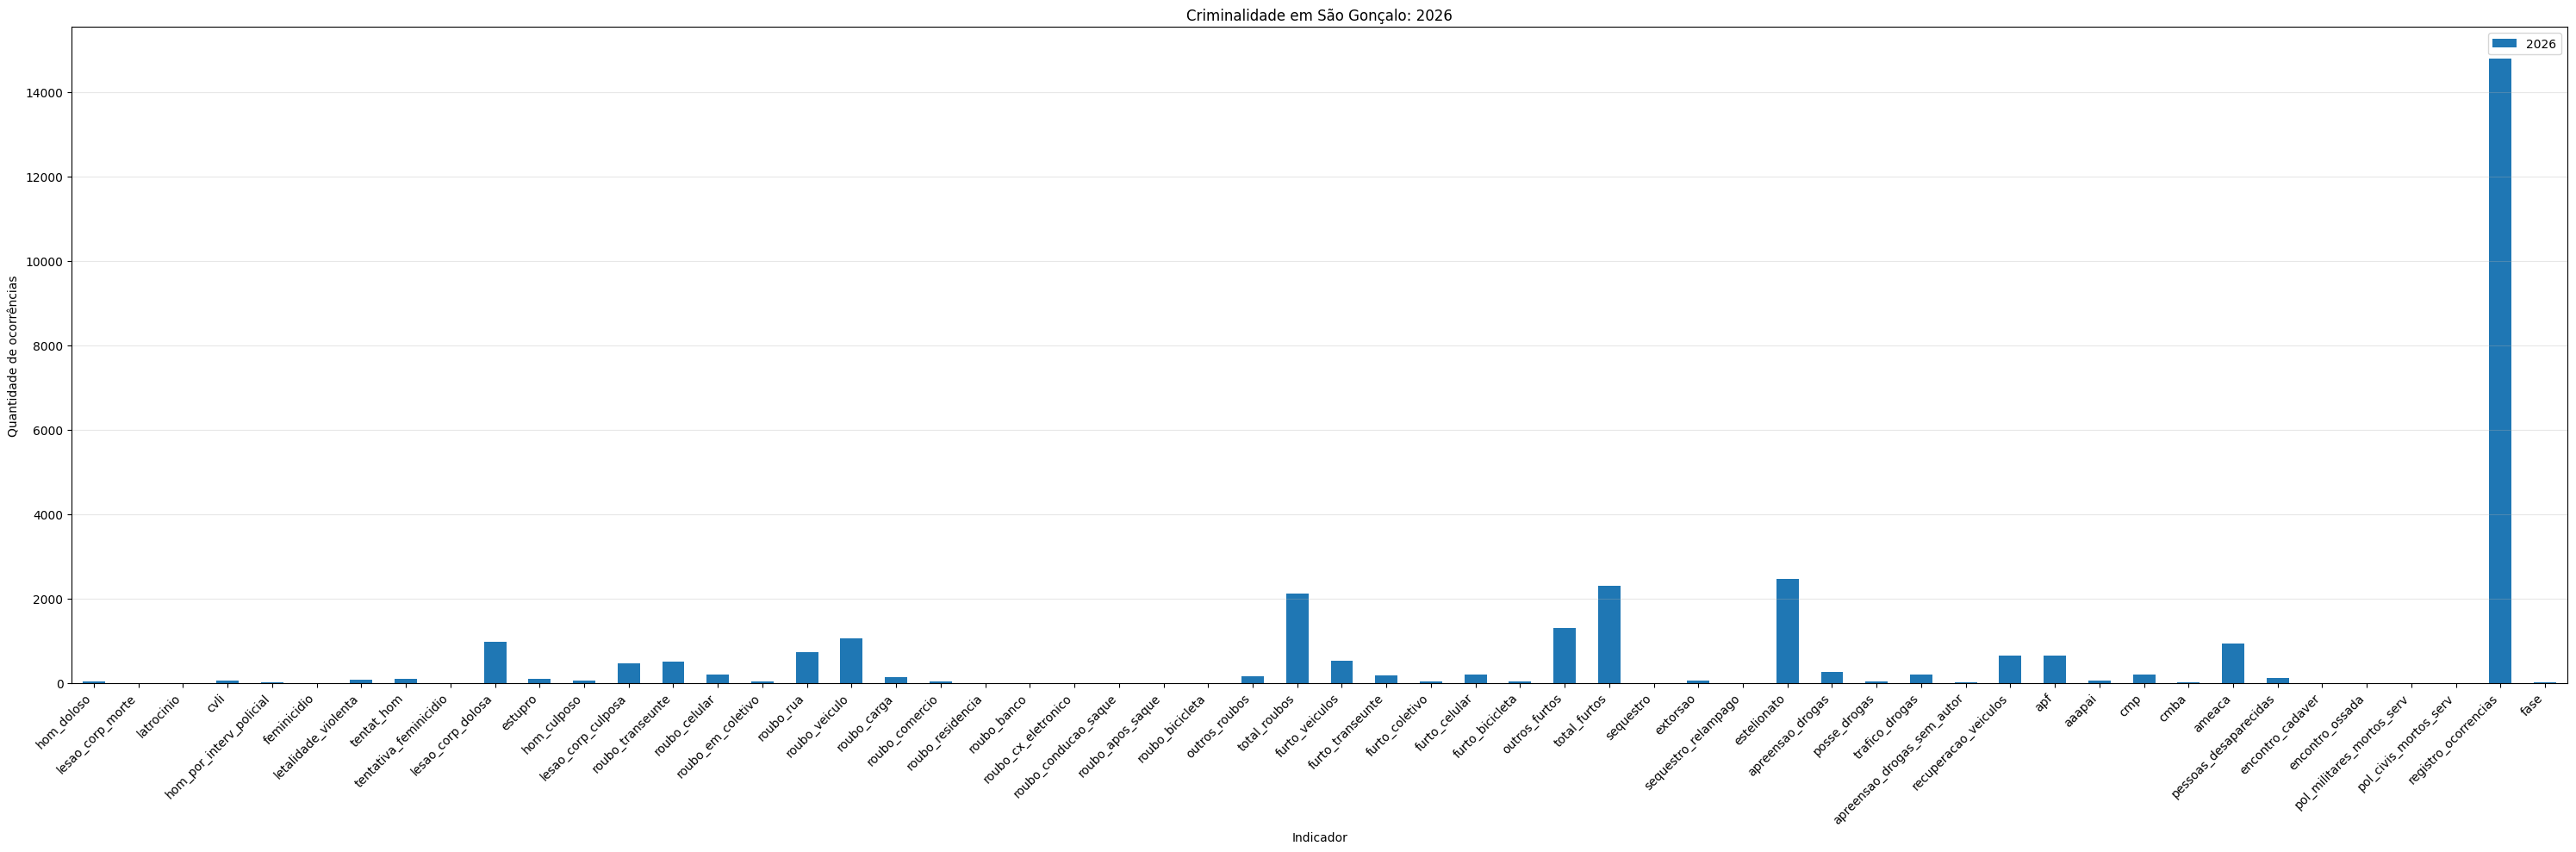

In [ ]:
import matplotlib.pyplot as plt

if not comparacao.empty:
    # Filter out 'fmun_cod' from the comparison DataFrame before plotting
    # as it's a code, not a crime indicator, and distorts the plot scale.
    plot_data = comparacao.drop(labels='fmun_cod', errors='ignore')

    plot_data[["2026"]].plot(
        kind="bar",
        figsize=(30, 10)
    )

    plt.title(
        "Criminalidade em São Gonçalo: 2026"
    )

    plt.xlabel("Indicador")

    plt.ylabel(
        "Quantidade de ocorrências"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()
else:
    print("Não há dados disponíveis para São Gonçalo para os anos selecionados para comparação.")
    print("Verifique os anos disponíveis para São Gonçalo e ajuste o filtro de anos.")

In [ ]:
principais = (
    estatisticas
    .sort_values(
        "sum",
        ascending=False
    )
    .head(10)
)

display(principais)

,count,sum,mean,min,max,std
tipo_crime,,,,,,
fmun_cod,1,16524520.0,16524520.0,16524520.0,16524520.0,NaN
registro_ocorrencias,1,14795.0,14795.0,14795.0,14795.0,NaN
estelionato,1,2475.0,2475.0,2475.0,2475.0,NaN
total_furtos,1,2306.0,2306.0,2306.0,2306.0,NaN
total_roubos,1,2119.0,2119.0,2119.0,2119.0,NaN
outros_furtos,1,1308.0,1308.0,1308.0,1308.0,NaN
roubo_veiculo,1,1054.0,1054.0,1054.0,1054.0,NaN
lesao_corp_dolosa,1,971.0,971.0,971.0,971.0,NaN
ameaca,1,938.0,938.0,938.0,938.0,NaN


In [ ]:
print("==========================================")
print("RESUMO DA ANÁLISE")
print("==========================================")

print("Município: São Gonçalo")
print("Período: 2014–2024")

print(
    "Quantidade de indicadores:",
    len(indicadores)
)

print(
    "Quantidade de anos:",
    df_pd[col_ano].nunique()
)

print(
    "Quantidade de linhas na análise:",
    len(df_long)
)

print("==========================================")
print("ANÁLISE CONCLUÍDA!")
print("==========================================")

RESUMO DA ANÁLISE
Município: São Gonçalo
Período: 2014–2024
Quantidade de indicadores: 57
Quantidade de anos: 1
Quantidade de linhas na análise: 57
ANÁLISE CONCLUÍDA!
